# What is the most optimal skill to learn for Data Analysts?

# Methodology

1. Group skills to determine median salary and likelihood of being in posting
2. Visualize median salary vs percent skill demand
3. Determine if certain technologies are more prevalent

In [1]:
#Importing Libraries
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import ast
import seaborn as sns

#Loading Dataset
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

#Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda skill_list: ast.literal_eval(skill_list) if pd.notna(skill_list) else skill_list)

In [12]:
#Filter for data analyst
df_DA_US = df[(df['job_title_short']=='Data Analyst') & (df['job_country'] == 'United States')].copy()

In [13]:
df_DA_US = df_DA_US.dropna(subset=['salary_year_avg'])

In [18]:
len(df_DA_US)

4350

In [14]:
df_DA_US_exploded = df_DA_US.explode('job_skills')

df_DA_US_exploded[['salary_year_avg','job_skills']].head(5)

,salary_year_avg,job_skills
109,89000.0,python
109,89000.0,r
109,89000.0,alteryx
109,89000.0,tableau
180,90250.0,excel


In [23]:
df_DA_skills = df_DA_US_exploded.groupby('job_skills')['salary_year_avg'].agg(['count','median']).sort_values(by='count',ascending=False)

df_DA_skills = df_DA_skills.rename(columns={'count':'skill_count','median':'median_salary'})

DA_job_count = len(df_DA_US) #we want to add the % of the skill as part of the whole set, so we need the total amount of the skill count
df_DA_skills['skill_percent'] = df_DA_skills['skill_count']/DA_job_count *100

skill_percent = 5

df_DA_skills_high_demand = df_DA_skills[df_DA_skills['skill_percent'] > skill_percent]

df_DA_skills_high_demand

,skill_count,median_salary,skill_percent
job_skills,,,
sql,2508,91000.00,57.655172
excel,1808,84392.00,41.563218
python,1431,97500.00,32.896552
tableau,1364,92875.00,31.356322
sas,926,90000.00,21.287356
r,893,92500.00,20.528736
power bi,838,90000.00,19.264368
powerpoint,462,85000.00,10.620690
word,461,81194.75,10.597701


In [33]:
from adjustText import adjust_text
from matplotlib.ticker import PercentFormatter


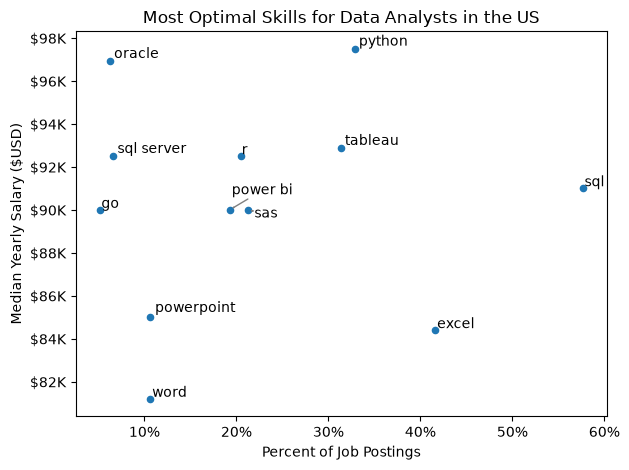

In [35]:
df_DA_skills_high_demand.plot(kind='scatter',x='skill_percent',y='median_salary')
#plt.text(x,y,string) example
texts = []
for i, txt in enumerate(df_DA_skills_high_demand.index):
    #trying to break it down into stages, we first want to print out the X,y values per i
    texts.append(plt.text(df_DA_skills_high_demand['skill_percent'].iloc[i],
             df_DA_skills_high_demand['median_salary'].iloc[i],
             txt))
adjust_text(texts,  arrowprops=dict(arrowstyle='->', color='gray', lw=1))
#    print(i,txt)

ax = plt.gca() #gca = get current axis, to access y axis to change values and add '$'
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))

plt.xlabel('Percent of Job Postings')
plt.ylabel('Median Yearly Salary ($USD)')
plt.title('Most Optimal Skills for Data Analysts in the US')
plt.tight_layout()
plt.show()

In [36]:
df['job_type_skills'].head(10)

0                                                  NaN
1    {'analyst_tools': ['power bi', 'tableau'], 'pr...
2    {'analyst_tools': ['dax'], 'cloud': ['azure'],...
3    {'cloud': ['aws'], 'libraries': ['tensorflow',...
4    {'cloud': ['oracle', 'aws'], 'other': ['ansibl...
5    {'cloud': ['gcp'], 'programming': ['python', '...
6    {'cloud': ['gcp', 'bigquery'], 'databases': ['...
7    {'cloud': ['gcp', 'azure', 'aws', 'bigquery', ...
8    {'analyst_tools': ['excel', 'powerpoint', 'pow...
9    {'analyst_tools': ['excel'], 'cloud': ['azure'...
Name: job_type_skills, dtype: str

Grouping different skills into distict types, and then putting them in seperate lists.

In [37]:
df_technology = df['job_type_skills'].copy()

#remove duplicates
df_technology = df_technology.drop_duplicates()

#remove NAN values
df_technology = df_technology.dropna()

technology_dict = {}
for row in df_technology:
    row_dict = ast.literal_eval(row) #convert string into dictionary
    for key,value in row_dict.items():
        if key in technology_dict: #if key already exists in technology_dict, add value to existing one
            technology_dict[key] += value
        else:                      #if key doesn't already exist in technology_dict, add key and value
            technology_dict[key] = value

for key,value in technology_dict.items():
    technology_dict[key] = list(set(value))

technology_dict

{'analyst_tools': ['ms access',
  'microstrategy',
  'qlik',
  'outlook',
  'ssis',
  'sheets',
  'dax',
  'tableau',
  'cognos',
  'spss',
  'visio',
  'sas',
  'datarobot',
  'nuix',
  'excel',
  'esquisse',
  'ssrs',
  'spreadsheet',
  'msaccess',
  'word',
  'powerpoint',
  'splunk',
  'alteryx',
  'sharepoint',
  'powerbi',
  'sap',
  'power bi',
  'looker'],
 'programming': ['visualbasic',
  'vb.net',
  'shell',
  'php',
  'delphi',
  'go',
  'apl',
  'matlab',
  'c',
  'assembly',
  'no-sql',
  'objective-c',
  'scala',
  'kotlin',
  'fortran',
  'erlang',
  'java',
  'swift',
  'perl',
  'f#',
  'powershell',
  'clojure',
  'sas',
  'c#',
  'julia',
  'groovy',
  'haskell',
  'rust',
  'visual basic',
  'solidity',
  'mongodb',
  'mongo',
  'golang',
  'bash',
  'dart',
  'lua',
  'ocaml',
  't-sql',
  'vba',
  'javascript',
  'c++',
  'r',
  'ruby',
  'elixir',
  'lisp',
  'crystal',
  'typescript',
  'css',
  'sql',
  'nosql',
  'cobol',
  'python',
  'html',
  'pascal',
  's

Turn the dictionary into a PD.Dataframe

In [40]:
df_technology = pd.DataFrame(list(technology_dict.items()),columns=['technology','skills'])

df_technology = df_technology.explode('skills')

df_technology

,technology,skills
0,analyst_tools,ms access
0,analyst_tools,microstrategy
0,analyst_tools,qlik
0,analyst_tools,outlook
0,analyst_tools,ssis
...,...,...
9,sync,unify
9,sync,symphony
9,sync,mattermost
9,sync,wire


In [42]:
df_plot = df_DA_skills_high_demand.merge(df_technology, left_on='job_skills',right_on='skills')

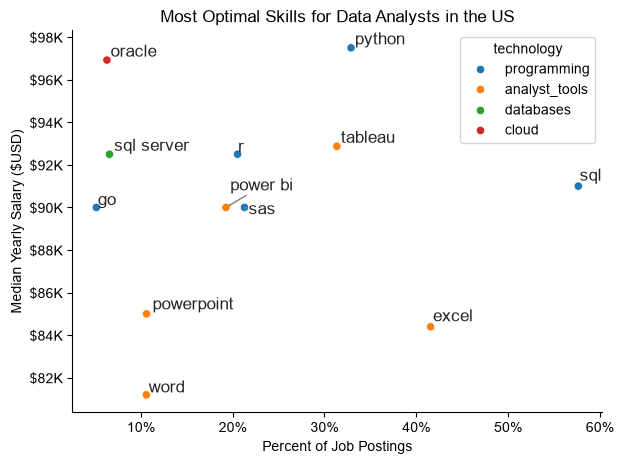

In [46]:
sns.scatterplot(
    data = df_plot,
    x='skill_percent',
    y='median_salary',
    hue='technology'
)
sns.despine()
sns.set_theme(style="ticks")
# df_plot.plot(kind='scatter',x='skill_percent',y='median_salary')
#plt.text(x,y,string) example
texts = []
for i, txt in enumerate(df_DA_skills_high_demand.index):
    #trying to break it down into stages, we first want to print out the X,y values per i
    texts.append(plt.text(df_DA_skills_high_demand['skill_percent'].iloc[i],
             df_DA_skills_high_demand['median_salary'].iloc[i],
             txt))
adjust_text(texts,  arrowprops=dict(arrowstyle='->', color='gray', lw=1))
#    print(i,txt)

ax = plt.gca() #gca = get current axis, to access y axis to change values and add '$'
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))

plt.xlabel('Percent of Job Postings')
plt.ylabel('Median Yearly Salary ($USD)')
plt.title('Most Optimal Skills for Data Analysts in the US')
plt.tight_layout()
plt.show()